# DAQ into pandas

A run into a DataFrame, scaled by the board's record.

In [1]:
SIMULATED = True          # False, and PORT, at the bench
PORT = 'COM4'

In [2]:
from coaxial import Coaxial63100

device = Coaxial63100(port=PORT, simulated_device=SIMULATED).open()
print(device)

<Coaxial63100 Simulated SIMULATED>


In [3]:
daq = device.daq
daq.open()
daq.enable()
device.set_time_from_pc(reference='pc')
daq.configure('phaseU', 'phaseV', 'phaseW', 'DC bus', 'NTC', sample_rate=100)
daq.start()
records = daq.read(300)
daq.stop()
print(len(records), 'records;', daq.channel_names(records[0]))

300 records; ['Phase U', 'Phase V', 'Phase W', 'NTC', 'DC bus']


`scaled=True` adds one column per channel in real units beside the codes, through the board's own converters and the channel trims in its calibration record (invariant 7). `stored` says whether that record was ever written or is the schematic's arithmetic; an uncalibrated board answers an empty record and every converter falls back to the compiled-in constant, which is what `name` says.

In [4]:
cal = device.calibration.read()
print('record stored:', cal['stored'], ' version:', cal['version'],
      ' params held:', len(cal['params']))
for name, params in sorted(device.analog.scaling().items()):
    print('%-8s %s' % (name, params.name))
print('channel trims:', [(c['index'], c['offset_raw'], c['gain_ppm'])
                         for c in cal['channels'][:3]])

record stored: False  version: 0  params held: 0
dcbus    compiled-in fallback, the board sent no record
ntc      compiled-in fallback, the board sent no record
phase    compiled-in fallback, the board sent no record
rail5    compiled-in fallback, the board sent no record
vgate    compiled-in fallback, the board sent no record
channel trims: [(0, 0, 0), (1, 0, 0), (2, 0, 0)]


In [5]:
df = daq.frame(records, index='elapsed', scaled=True)
df.head()

,Phase U,Phase V,Phase W,NTC,DC bus,AFE_ON,nFAULT/TIM1_BKIN,KEEPALIVE,TIM1_CH1N/PWMUL,TIM1_CH1/PWMUH,...,TIM1_CH2/PWMVH,TIM1_CH3N/PWMWL,TIM1_CH3/PWMWH,time,dt,Phase U (A),Phase V (A),Phase W (A),NTC (C),DC bus (V)
elapsed,,,,,,,,,,,,,,,,,,,,,
0.00,8812.730769,-7320.115385,-7774.038462,34999.115385,18483.961538,1.0,1.0,0.537457,0.0,0.0,...,0.0,0.0,0.0,1.788411e+09,0.01,55.786498,-46.337919,-49.211350,28.630647,22.041650
0.01,8819.538462,-7303.846154,-7765.653846,35001.576923,18490.769231,1.0,1.0,0.498579,0.0,0.0,...,0.0,0.0,0.0,1.788411e+09,0.01,55.829592,-46.234931,-49.158274,28.634714,22.049768
0.02,8808.000000,-7307.576923,-7778.730769,35007.923077,18484.961538,1.0,1.0,0.465308,0.0,0.0,...,0.0,0.0,0.0,1.788411e+09,0.01,55.756551,-46.258548,-49.241054,28.645200,22.042843
0.03,8806.730769,-7325.115385,-7756.461538,35011.038462,18490.153846,1.0,1.0,0.528610,0.0,0.0,...,0.0,0.0,0.0,1.788411e+09,0.01,55.748517,-46.369570,-49.100085,28.650349,22.049034
0.04,8815.884615,-7320.076923,-7749.653846,35025.846154,18481.230769,1.0,1.0,0.517364,0.0,0.0,...,0.0,0.0,0.0,1.788411e+09,0.01,55.806463,-46.337675,-49.056991,28.674821,22.038394


In [6]:
df.describe().round(3)

,Phase U,Phase V,Phase W,NTC,DC bus,AFE_ON,nFAULT/TIM1_BKIN,KEEPALIVE,TIM1_CH1N/PWMUL,TIM1_CH1/PWMUH,...,TIM1_CH2/PWMVH,TIM1_CH3N/PWMWL,TIM1_CH3/PWMWH,time,dt,Phase U (A),Phase V (A),Phase W (A),NTC (C),DC bus (V)
count,300.000,300.000,300.000,300.000,300.000,300.0,300.0,300.000,300.0,300.0,...,300.0,300.0,300.0,3.000000e+02,300.00,300.000,300.000,300.000,300.000,300.000
mean,5486.772,-3569.434,-8186.537,35064.221,18997.029,1.0,1.0,0.501,0.0,0.0,...,0.0,0.0,0.0,1.788411e+09,0.01,34.732,-22.595,-51.823,28.738,22.653
std,2519.899,2311.827,448.618,77.132,356.403,0.0,0.0,0.021,0.0,0.0,...,0.0,0.0,0.0,8.670000e-01,0.00,15.952,14.634,2.840,0.128,0.425
min,471.308,-7325.115,-8649.154,34982.846,18481.231,1.0,1.0,0.456,0.0,0.0,...,0.0,0.0,0.0,1.788411e+09,0.01,2.983,-46.370,-54.751,28.604,22.038
25%,3406.298,-5566.019,-8558.827,35006.433,18690.673,1.0,1.0,0.488,0.0,0.0,...,0.0,0.0,0.0,1.788411e+09,0.01,21.563,-35.234,-54.179,28.643,22.288
50%,6161.538,-3800.538,-8326.654,35024.635,18916.404,1.0,1.0,0.500,0.0,0.0,...,0.0,0.0,0.0,1.788411e+09,0.01,39.004,-24.058,-52.710,28.673,22.557
75%,7668.394,-1435.202,-7967.240,35108.115,19292.317,1.0,1.0,0.514,0.0,0.0,...,0.0,0.0,0.0,1.788411e+09,0.01,48.543,-9.085,-50.434,28.811,23.006
max,8827.192,189.077,-6926.115,35265.769,19689.000,1.0,1.0,0.570,0.0,0.0,...,0.0,0.0,0.0,1.788411e+09,0.01,55.878,1.197,-43.844,29.072,23.479


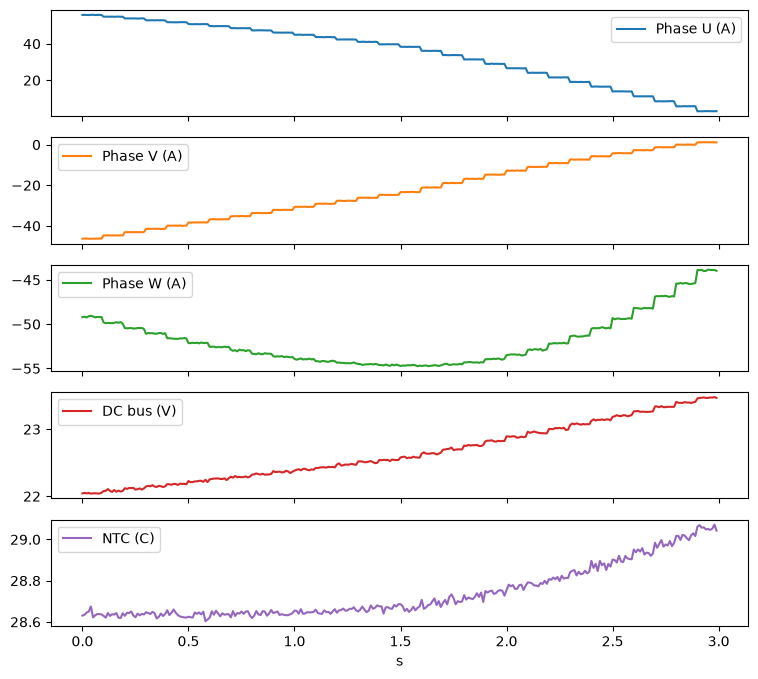

In [7]:
import matplotlib.pyplot as plt

units = [c for c in df.columns if c.endswith('(A)')]
axes = df[units + ['DC bus (V)', 'NTC (C)']].plot(subplots=True, figsize=(9, 8), legend=True)
axes[-1].set_xlabel('s')
plt.show()

The codes stay in the frame under the board's own channel names, so a tare or a span can be checked against what arrived.

In [8]:
print(df[['Phase U', 'Phase U (A)', 'NTC', 'NTC (C)']].iloc[:3])
device.close()

             Phase U  Phase U (A)           NTC    NTC (C)
elapsed                                                   
0.00     8812.730769    55.786498  34999.115385  28.630647
0.01     8819.538462    55.829592  35001.576923  28.634714
0.02     8808.000000    55.756551  35007.923077  28.645200


## Conclusions

In [9]:
codes = [c for c in df.columns if not c.endswith(')')]
scaled = [c for c in df.columns if c.endswith(')')]
print('%d records, %d code columns, %d scaled columns' % (len(df), len(codes), len(scaled)))
for name in ('Phase U', 'DC bus', 'NTC'):
    unit = [c for c in scaled if c.startswith(name)][0]
    span = df[unit].max() - df[unit].min()
    print('%-8s codes %8.1f +/- %6.1f   %-12s %8.3f +/- %.3f  span %.3f'
          % (name, df[name].mean(), df[name].std(), unit, df[unit].mean(),
             df[unit].std(), span))

300 records, 16 code columns, 5 scaled columns
Phase U  codes   5486.8 +/- 2519.9   Phase U (A)    34.732 +/- 15.952  span 52.895
DC bus   codes  18997.0 +/-  356.4   DC bus (V)     22.653 +/- 0.425  span 1.440
NTC      codes  35064.2 +/-   77.1   NTC (C)        28.738 +/- 0.128  span 0.468


A code column is what arrived; the column beside it is what it means. The conversion is the board's own (invariant 7): every scaling parameter lives in the calibration record and `frame(scaled=True)` asks `board.analog.scaling()` for it rather than holding a constant, then applies that channel's stored offset and gain trim. Keeping both is deliberate - what arrived and what it means are two columns, not one that quietly became the other, and a tare that stored an offset no column used is exactly the failure that shape prevents.

With an empty record every converter falls back to the compiled-in constant and says so in `name`. `calibration.span(index, reference)` is what writes a channel's gain trim against an instrument, and it takes the reference in that channel's own unit - milliamperes for a phase, millivolts for the DC link. The DC link's stands at -32 418 ppm, 31.04 V read against 30.05 V true (FINDINGS).

The DC link's divider is 49.9k/2.2k: 78.15 V full scale on a 63 V rating, 24 % of headroom kept on purpose so an over-rating transient is recorded rather than clipped (invariant 11).